# Neural Quantum States for the XXZ Chain

Project 22, PHYS-EV0007, Aalto University. Reproduce the NetKet **Ground-State: Heisenberg** tutorial and extend it to the **XXZ phase diagram**.

Hamiltonian (Pauli normalisation, periodic BC):

$$H_{XXZ}(\Delta) = \sum_{i=1}^{L}\left(\sigma^x_i\sigma^x_{i+1} + \sigma^y_i\sigma^y_{i+1} + \Delta\,\sigma^z_i\sigma^z_{i+1}\right).$$

Sector $S^z_\text{tot}=0$. We scan $\Delta\in[0,3]$ through the XY (Luttinger-liquid) phase, the BKT point at $\Delta=1$, and into the Ising AFM phase.

**Workflow.** (i) reproduce four ansätze at $\Delta=1$, $L=22$; (ii) sweep $\Delta$ for Jastrow / RBM / RBMSymm at $L\in\{16,22,28\}$ and deeper FFNN at four $\Delta$; (iii) benchmark against Bethe-ansatz energy and Lanczos at $\Delta=1$; (iv) measure $E_0/L$, $\sigma_E^2$, $S_\text{AFM}(\pi)$, $C^x(r)$, $\langle\sigma^z_i\sigma^z_j\rangle_c$.


## Setup

JAX on CPU, persistent compilation cache, results directory.


In [1]:
import os

os.environ["JAX_PLATFORM_NAME"] = "cpu"

import json
import time
import pickle
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx, serialization
import matplotlib.pyplot as plt
from scipy.integrate import quad

import netket as nk
from jax.experimental.compilation_cache import compilation_cache as cc

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)
(RESULTS / "jax_cache").mkdir(exist_ok=True)
(RESULTS / "heisenberg").mkdir(exist_ok=True)
(RESULTS / "xxz").mkdir(exist_ok=True)
cc.set_cache_dir(str(RESULTS / "jax_cache"))

print(f"netket {nk.__version__} | jax {jax.__version__}")

∣NK⟩ Tip: Debug multi-node HPC? `djaxrun -np 2 python Examples/Sharding/multi_process.py`

netket 3.21.0 | jax 0.7.2


## 1. Model: XXZ chain

Pauli operators $\sigma^\alpha$, so $\vec\sigma = 2\vec S$ and $H_{XXZ}$ above is **4 ×** the conventional $\vec S$-form. Phase diagram in $\Delta$:

| range | phase |
|---|---|
| $\Delta<-1$ | gapped ferromagnet |
| $-1<\Delta\le1$ | gapless XY / Luttinger liquid |
| $\Delta=1$ | BKT (isotropic Heisenberg) |
| $\Delta>1$ | gapped Ising-like AFM |

We work in the $S^z_\text{tot}=0$ sector (block-diagonal in the AFM-relevant subspace).


In [2]:
def make_space(L: int):
    g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
    hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=g.n_nodes)
    return g, hi


L = 22
g, hi = make_space(L)
print(f"L={L}, dim(H)={hi.n_states}")

L=22, dim(H)=705432


### XXZ Hamiltonian as PauliStrings, with Marshall sign rule

NetKet 3.21 aliases `nk.operator.PauliStrings` to the JAX backend (`PauliStringsJax`); building $H$ directly as a sum of Pauli strings avoids the slower `LocalOperator` path (Claude Opus 4.7, 2026).

For even $L$ the chain is bipartite. The Marshall–Peierls rotation [1] $U = \prod_{j\in B}\sigma^z_j$ flips $\sigma^{x,y}\to-\sigma^{x,y}$ on the $B$ sublattice and leaves $\sigma^z$ alone, giving the unitarily equivalent

$$\tilde H = -\sum (\sigma^x_i\sigma^x_{i+1} + \sigma^y_i\sigma^y_{i+1}) + \Delta\sum\sigma^z_i\sigma^z_{i+1}.$$

The eigenvalues are unchanged but $\tilde H$ is **stoquastic** [2] in the $\sigma^z$ basis (all off-diagonal matrix elements $\le 0$), so the ground state is real-positive and VMC converges across the whole $\Delta$ range with the same hyperparameters as the Heisenberg point. We work with $\tilde H$ throughout and translate observables back as needed: $\langle\sigma^z_i\sigma^z_j\rangle$ and $S_\text{AFM}(\pi)$ are unchanged, $\langle\sigma^x_0\sigma^x_r\rangle = (-1)^r\,\langle\sigma^x_0\sigma^x_r\rangle_{\tilde H}$.


In [3]:
def build_xxz(hi, graph, Delta: float, sign_rule: bool = True):
    L = hi.size
    s = -1.0 if sign_rule else 1.0
    strings, weights = [], []
    for i, j in graph.edges():
        sx = ["I"] * L
        sx[i] = "X"
        sx[j] = "X"

        sy = ["I"] * L
        sy[i] = "Y"
        sy[j] = "Y"

        sz = ["I"] * L
        sz[i] = "Z"
        sz[j] = "Z"

        strings += ["".join(sx), "".join(sy), "".join(sz)]
        weights += [s, s, float(Delta)]
    return nk.operator.PauliStrings(hi, strings, weights)


ha = build_xxz(hi, g, Delta=1.0)
print(
    ha.__class__.__name__,
    "with",
    len(ha.operators),
    "Pauli strings (Marshall-rotated)",
)

PauliStringsJax with 66 Pauli strings (Marshall-rotated)


## 2. Bethe-ansatz benchmark

Thermodynamic-limit ground-state energy per site (Pauli normalisation, $e_0 = 4\,e_0^{\rm spin}$).

- **XY**, $-1<\Delta<1$, $\Delta=\cos\zeta$ (Cloizeaux–Pearson 1966, Caux notes):

  $$e_0(\Delta) \;=\; \Delta \;-\; \sin\zeta\,\int_{-\infty}^{\infty}\!\!\Big[1-\frac{\tanh(\omega\zeta/2)}{\tanh(\omega\pi/2)}\Big]\,d\omega.$$
- **Heisenberg** $\Delta=1$ (Hulthén 1938): $e_0(1)=1-4\ln 2\approx -1.77259$.
- **Ising-AFM** $\Delta>1$, $\Delta=\cosh\eta$ (Yang–Yang 1966):

  $$e_0(\Delta) \;=\; \Delta \;-\; 2\sinh\eta\,\Big[1+4\sum_{n=1}^{\infty}\frac{1}{1+e^{2n\eta}}\Big].$$


In [4]:
def bethe_energy_per_site(Delta: float) -> float:
    if abs(Delta - 1.0) < 1e-12:
        return 1.0 - 4.0 * np.log(2.0)

    if -1.0 < Delta < 1.0:
        zeta = np.arccos(Delta)

        def f(w):
            if w < 1e-12:
                return 1.0 - zeta / np.pi  # l'Hopital at w -> 0

            return 1.0 - np.tanh(w * zeta / 2.0) / np.tanh(w * np.pi / 2.0)

        I, _ = quad(f, 0.0, np.inf, limit=300)
        return float(Delta - 2.0 * np.sin(zeta) * I)

    if Delta > 1.0:
        eta = np.arccosh(Delta)
        n_max = max(200, int(50.0 / max(eta, 1e-3)))
        n = np.arange(1, n_max)
        S = float(np.sum(1.0 / (1.0 + np.exp(2.0 * n * eta))))
        return float(Delta - 2.0 * np.sinh(eta) * (1.0 + 4.0 * S))

    raise ValueError("Bethe formula here is only for Delta > -1")


# checkpoints: Hulthen and free-fermion XX
print(f"Bethe e0(Delta=1)  = {bethe_energy_per_site(1.0):+.6f}  (Hulthen)")
print(
    f"Bethe e0(Delta=0)  = {bethe_energy_per_site(0.0):+.6f}  vs -4/pi = {-4 / np.pi:+.6f}"
)

Bethe e0(Delta=1)  = -1.772589  (Hulthen)
Bethe e0(Delta=0)  = -1.273240  vs -4/pi = -1.273240


## 3. Lanczos benchmark at $\Delta=1$, $L=22$

Reference for all NQS ansätze in Section 4. The PDF quotes $E_0 \simeq -39.1475$.


In [5]:
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
E_exact = float(evals[0])
print(f"E0(L={L}, Delta=1) = {E_exact:.6f}")
print(f"thermodynamic limit estimate L*e0 = {L * bethe_energy_per_site(1.0):.6f}")

E0(L=22, Delta=1) = -39.147523
thermodynamic limit estimate L*e0 = -38.996952


## 4. NQS architectures at the Heisenberg point

Four ansätze in order of growing expressivity. Same sampler (`MetropolisExchange`, preserves $S^z_\text{tot}$), same VMC+SR driver (`VMC_SR`), 1008 samples / step.

### 4.1 Jastrow

$$\log\psi(\sigma) = \sum_i v_i\sigma_i + \sum_{i,j}\sigma_i J_{ij}\sigma_j.$$


In [6]:
class Jastrow(nnx.Module):
    def __init__(self, N: int, *, rngs: nnx.Rngs):
        k1, k2 = jax.random.split(rngs.params())
        self.J = nnx.Param(0.01 * jax.random.normal(k1, (N, N), dtype=jnp.complex128))
        self.v = nnx.Param(0.01 * jax.random.normal(k2, (N,), dtype=jnp.complex128))

    def __call__(self, x):
        x = x.astype(jnp.complex128)
        return jnp.einsum("...i,ij,...j->...", x, self.J, x) + x @ self.v

In [7]:
def vmc_train(
    model, ha, hi, graph, n_iter, lr, diag_shift, out_prefix, n_samples=1008, seed=0
):

    sa = nk.sampler.MetropolisExchange(hilbert=hi, graph=graph)
    vs = nk.vqs.MCState(sa, model, n_samples=n_samples, seed=seed)
    op = nk.optimizer.Sgd(learning_rate=lr)
    gs = nk.driver.VMC_SR(
        hamiltonian=ha, optimizer=op, diag_shift=diag_shift, variational_state=vs
    )
    t0 = time.time()

    gs.run(n_iter=n_iter, out=str(RESULTS / "heisenberg" / out_prefix))
    return vs, time.time() - t0


ja_model = Jastrow(N=hi.size, rngs=nnx.Rngs(0))

vs_ja, t_ja = vmc_train(
    ja_model, ha, hi, g, n_iter=300, lr=0.01, diag_shift=0.1, out_prefix="Jastrow"
)

print(f"Jastrow: {vs_ja.n_parameters} params, {t_ja:.1f}s")

Automatic SR implementation choice:  QGT


  0%|          | 0/300 [00:00<?, ?it/s]

Jastrow: 506 params, 13.1s


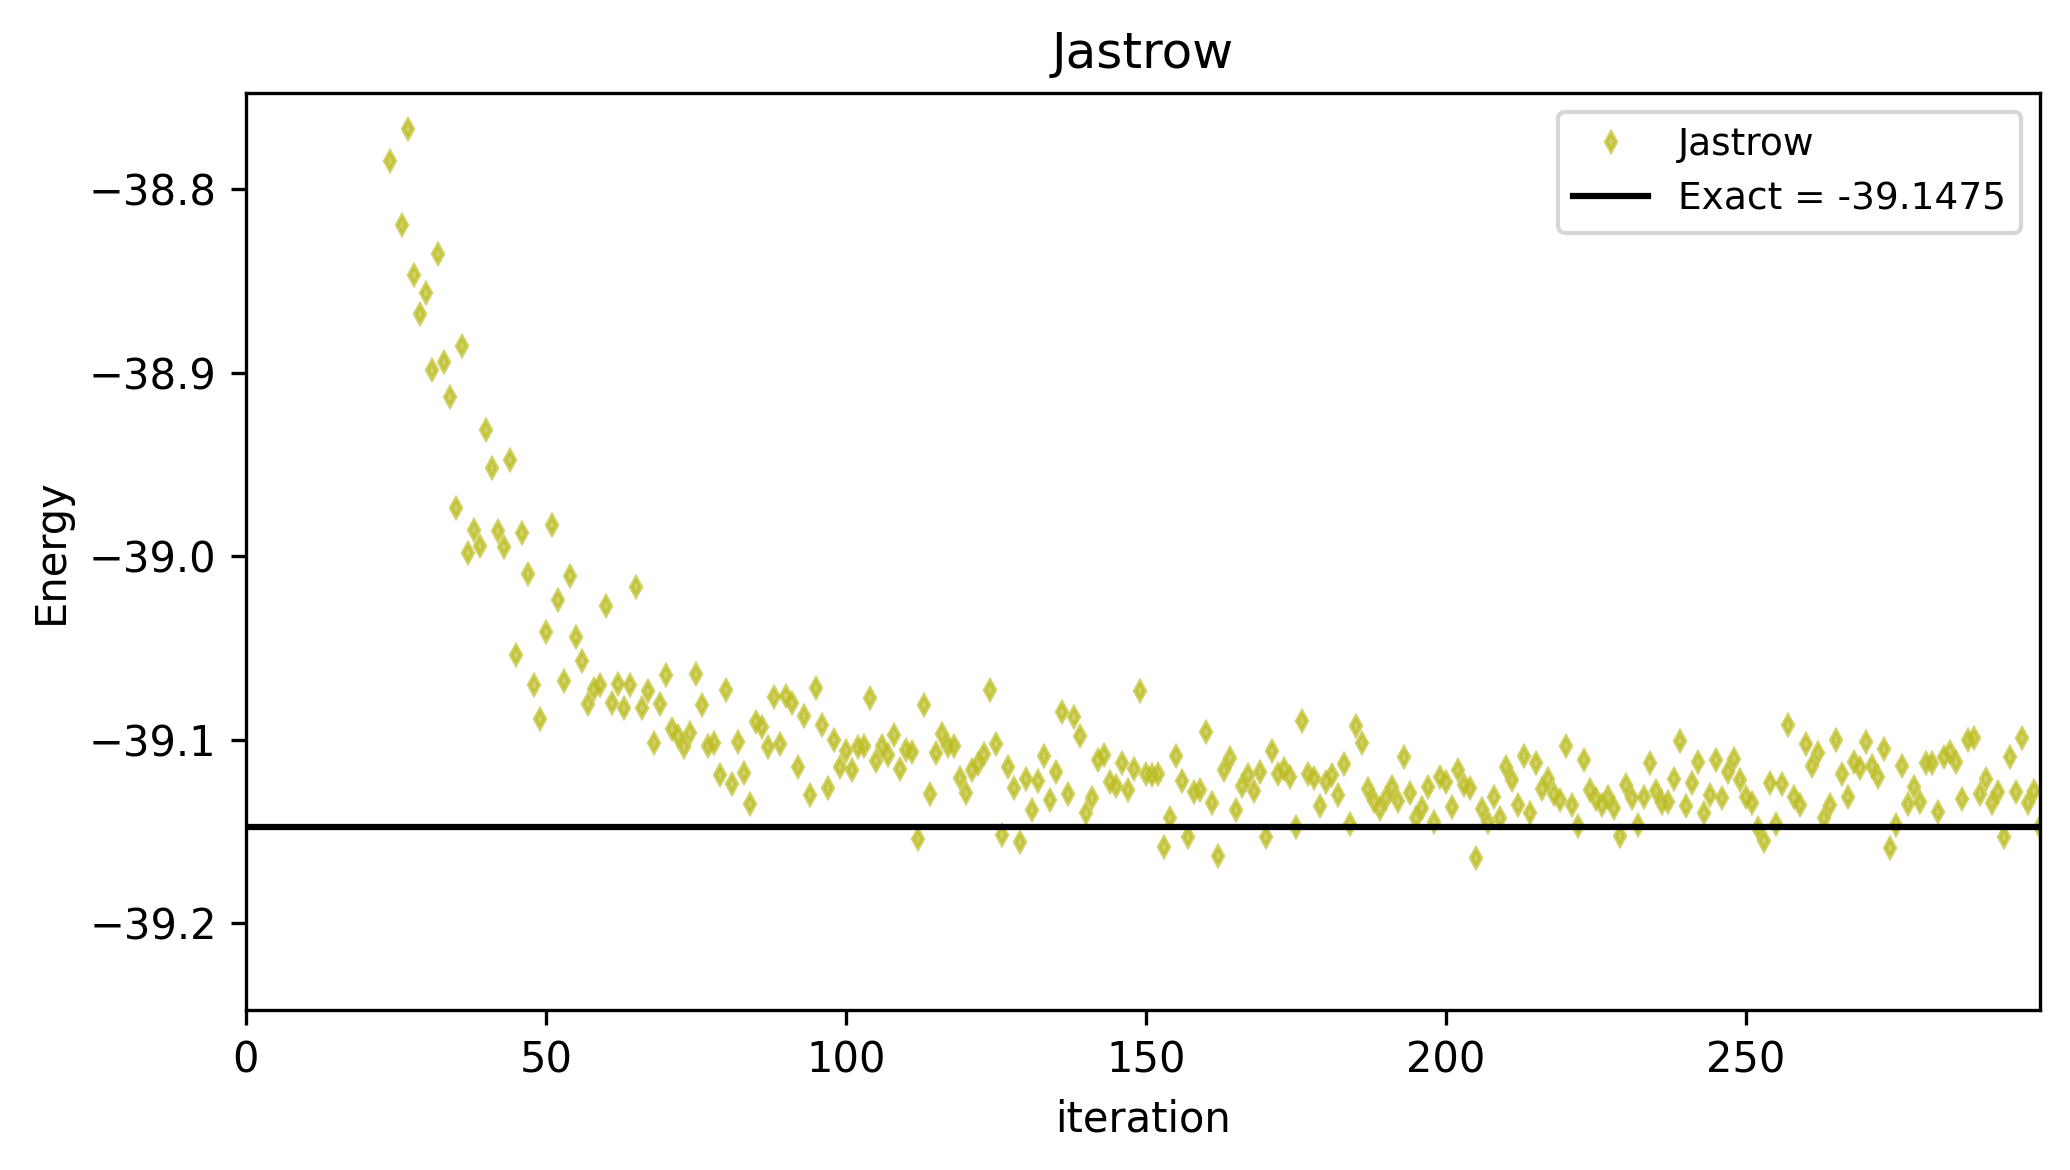

In [8]:
def load_log(prefix):
    d = json.load(open(RESULTS / "heisenberg" / f"{prefix}.log"))
    e = d["Energy"]["Mean"]
    if isinstance(e, dict):
        e = e["real"]
    return d["Energy"]["iters"], e


def plot_traces(traces, E_exact, ymin=-0.1, ymax=0.4, title=None):
    fig, ax = plt.subplots(figsize=(7, 4), dpi=300)

    for label, (it, en, color, marker) in traces.items():
        ax.plot(
            it,
            en,
            color=color,
            marker=marker,
            linestyle="None",
            markersize=3,
            alpha=0.7,
            label=label,
        )

    ax.axhline(E_exact, color="k", lw=1.5, label=f"Exact = {E_exact:.4f}")
    ax.set_xlabel("iteration")
    ax.set_ylabel("Energy")
    last = max(t[0][-1] for t in traces.values())
    ax.set_xlim(0, last)
    ax.set_ylim(E_exact + ymin, E_exact + ymax)
    if title:
        ax.set_title(title)
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()


it_ja, e_ja = load_log("Jastrow")
plot_traces({"Jastrow": (it_ja, e_ja, "C8", "d")}, E_exact, title="Jastrow")


### 4.2 RBM

$$\log\psi_\text{RBM}(\sigma) = \sum_i a_i\sigma_i + \sum_{j=1}^{\alpha L}\log\cosh\!\Big(b_j + \sum_i W_{ji}\sigma_i\Big),\quad \alpha = M/L.$$

Fully connected; no symmetry imposed.


Automatic SR implementation choice:  QGT


  0%|          | 0/600 [00:00<?, ?it/s]

RBM: 528 params, 16.1s


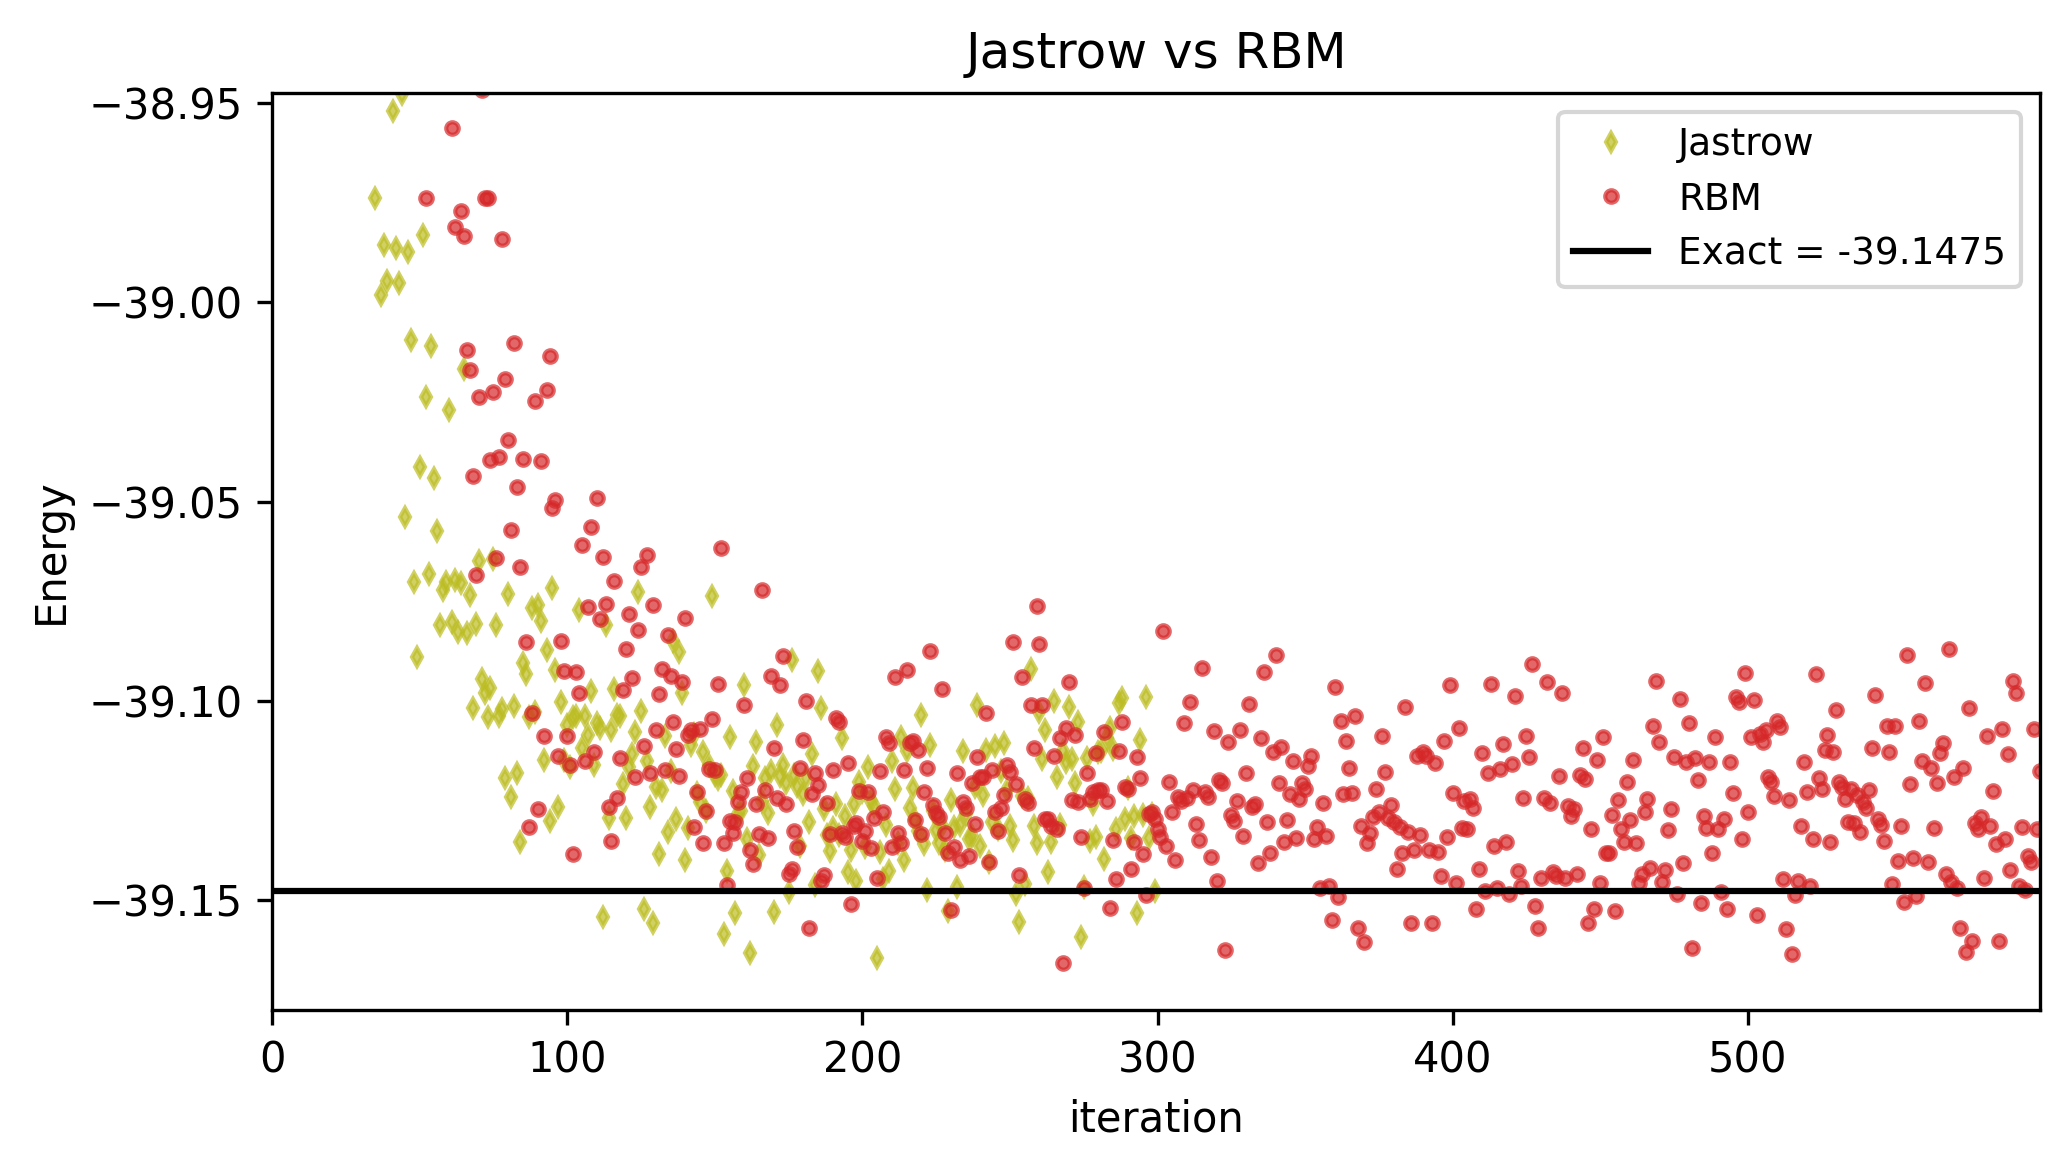

In [9]:
vs_rbm, t_rbm = vmc_train(
    nk.models.RBM(alpha=1),
    ha,
    hi,
    g,
    n_iter=600,
    lr=0.05,
    diag_shift=0.1,
    out_prefix="RBM",
)

print(f"RBM: {vs_rbm.n_parameters} params, {t_rbm:.1f}s")
it_rbm, e_rbm = load_log("RBM")

plot_traces(
    {"Jastrow": (it_ja, e_ja, "C8", "d"), "RBM": (it_rbm, e_rbm, "C3", "o")},
    E_exact,
    ymin=-0.03,
    ymax=0.2,
    title="Jastrow vs RBM",
)


### 4.3 Translation-symmetric RBM

Weight-tying across the translation group $\mathbb{Z}_L$ reduces parameters by a factor $\sim L$ at the same $\alpha$. NetKet enforces $\alpha\ge n_\text{symm}/n_\text{sites}=1$ on a chain.


Automatic SR implementation choice:  QGT


  0%|          | 0/300 [00:00<?, ?it/s]

RBMSymm: 24 params, 7.9s


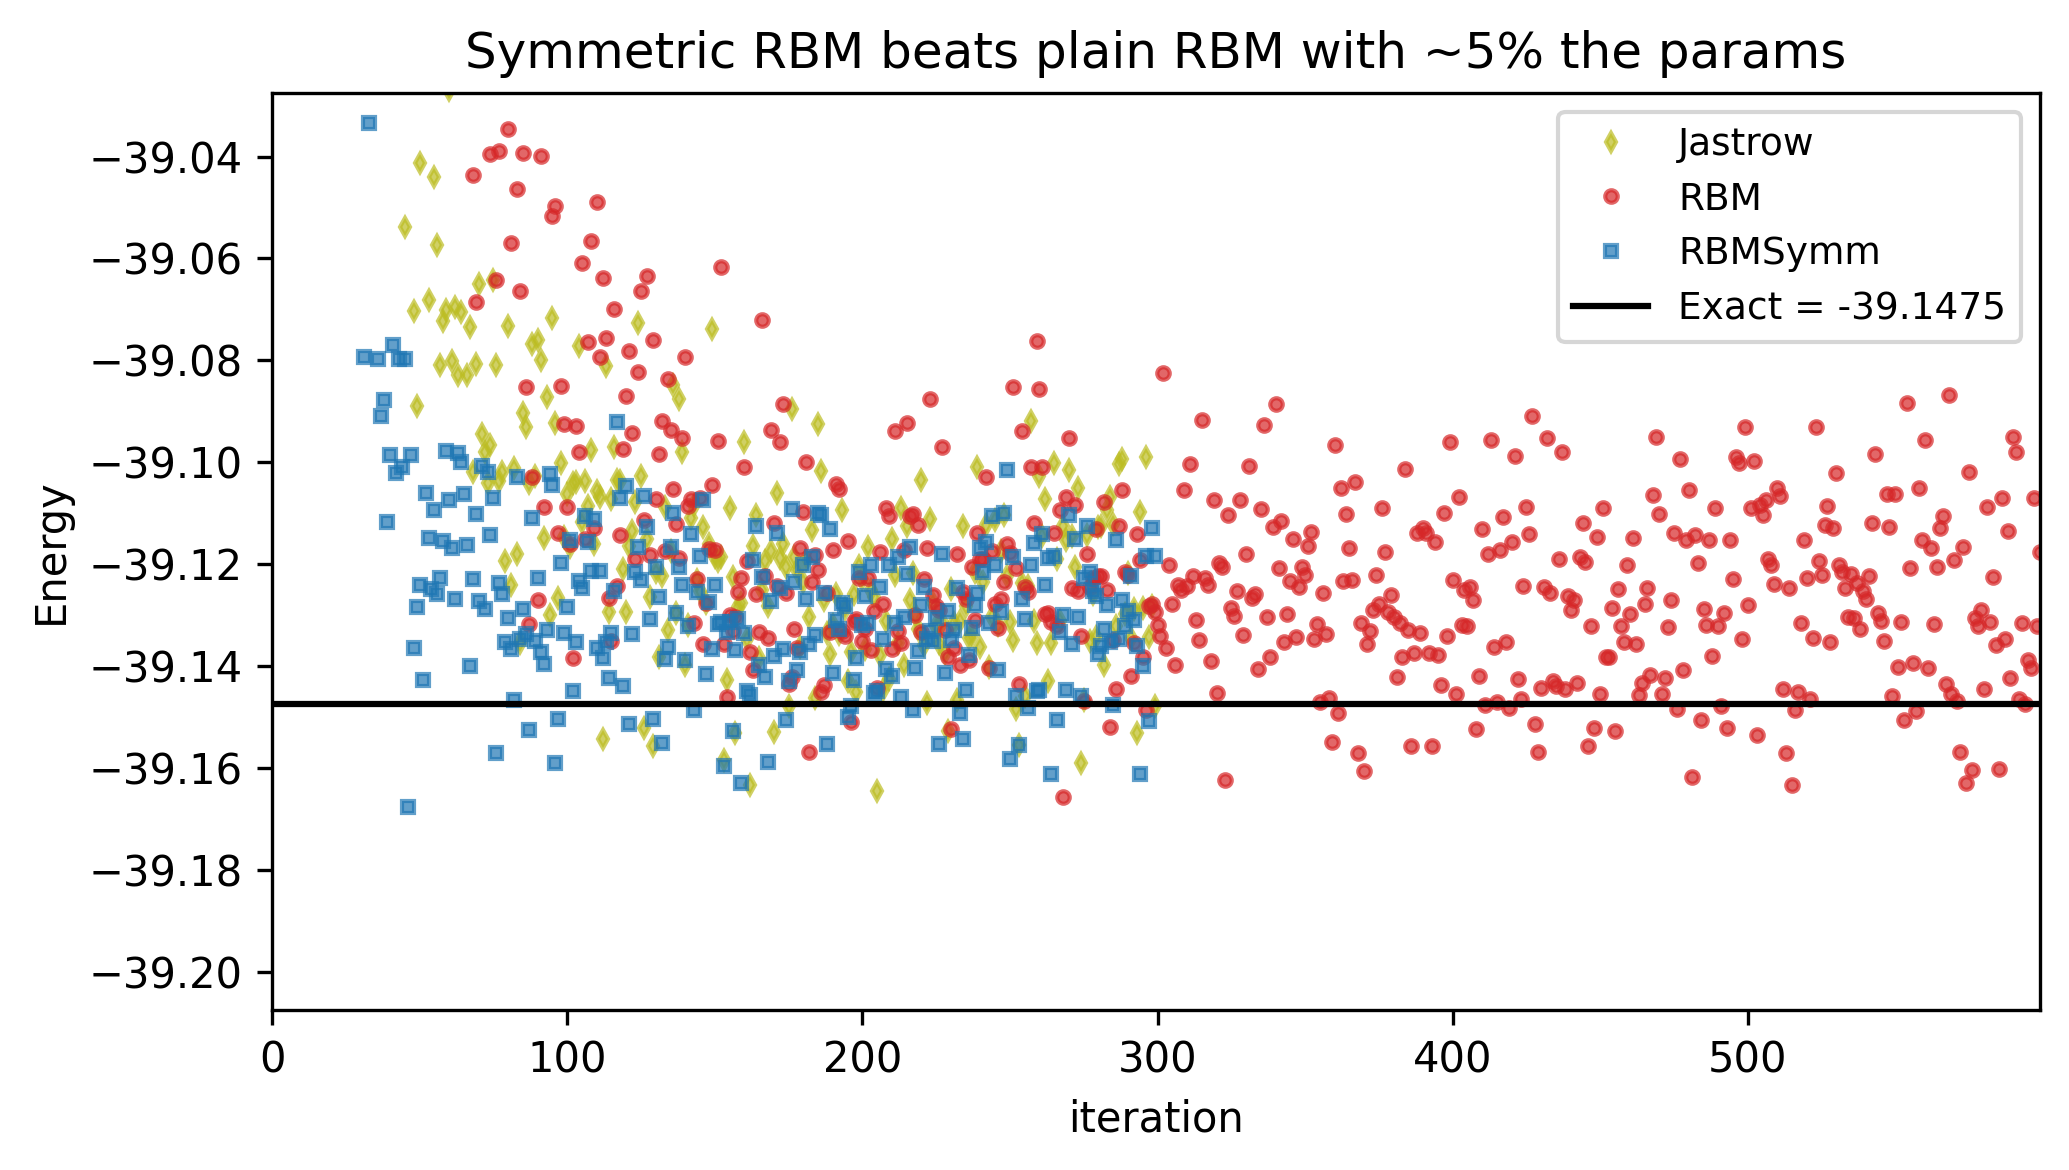

In [10]:
vs_sym, t_sym = vmc_train(
    nk.models.RBMSymm(symmetries=g.translation_group(), alpha=1),
    ha,
    hi,
    g,
    n_iter=300,
    lr=0.01,
    diag_shift=0.1,
    out_prefix="RBMSymmetric",
)


print(f"RBMSymm: {vs_sym.n_parameters} params, {t_sym:.1f}s")
it_sym, e_sym = load_log("RBMSymmetric")
plot_traces(
    {
        "Jastrow": (it_ja, e_ja, "C8", "d"),
        "RBM": (it_rbm, e_rbm, "C3", "o"),
        "RBMSymm": (it_sym, e_sym, "C0", "s"),
    },
    E_exact,
    ymin=-0.06,
    ymax=0.12,
    title="Symmetric RBM beats plain RBM with ~5% the params",
)


### 4.4 Feed-forward neural network

Shallow: one complex-valued dense layer $\mathbb{C}^L\to\mathbb{C}^{2L}$, log-cosh activation, sum-reduce. Deeper variant adds a second layer.


In [11]:
class FFNN1(nnx.Module):
    def __init__(self, N, *, rngs):
        self.lin = nnx.Linear(
            in_features=N, out_features=2 * N, dtype=jnp.complex128, rngs=rngs
        )

    def __call__(self, x):
        return jnp.sum(nk.nn.activation.log_cosh(self.lin(x)), axis=-1)


class FFNN2(nnx.Module):
    def __init__(self, N, *, rngs):
        self.l1 = nnx.Linear(
            in_features=N, out_features=2 * N, dtype=jnp.complex128, rngs=rngs
        )
        self.l2 = nnx.Linear(
            in_features=2 * N, out_features=N, dtype=jnp.complex128, rngs=rngs
        )

    def __call__(self, x):
        x = nk.nn.activation.log_cosh(self.l1(x))
        x = nk.nn.activation.log_cosh(self.l2(x))
        return jnp.sum(x, axis=-1)


In [12]:
vs_ff1, t_ff1 = vmc_train(
    FFNN1(N=hi.size, rngs=nnx.Rngs(1)),
    ha,
    hi,
    g,
    n_iter=300,
    lr=0.05,
    diag_shift=0.1,
    out_prefix="FF",
)
print(f"FFNN-1L: {vs_ff1.n_parameters} params, {t_ff1:.1f}s")

vs_ff2, t_ff2 = vmc_train(
    FFNN2(N=hi.size, rngs=nnx.Rngs(1)),
    ha,
    hi,
    g,
    n_iter=600,
    lr=0.05,
    diag_shift=0.1,
    out_prefix="FF2",
)
print(f"FFNN-2L: {vs_ff2.n_parameters} params, {t_ff2:.1f}s")


Automatic SR implementation choice:  NTK


  0%|          | 0/300 [00:00<?, ?it/s]

FFNN-1L: 1012 params, 63.4s
Automatic SR implementation choice:  NTK


  0%|          | 0/600 [00:00<?, ?it/s]

FFNN-2L: 2002 params, 166.2s


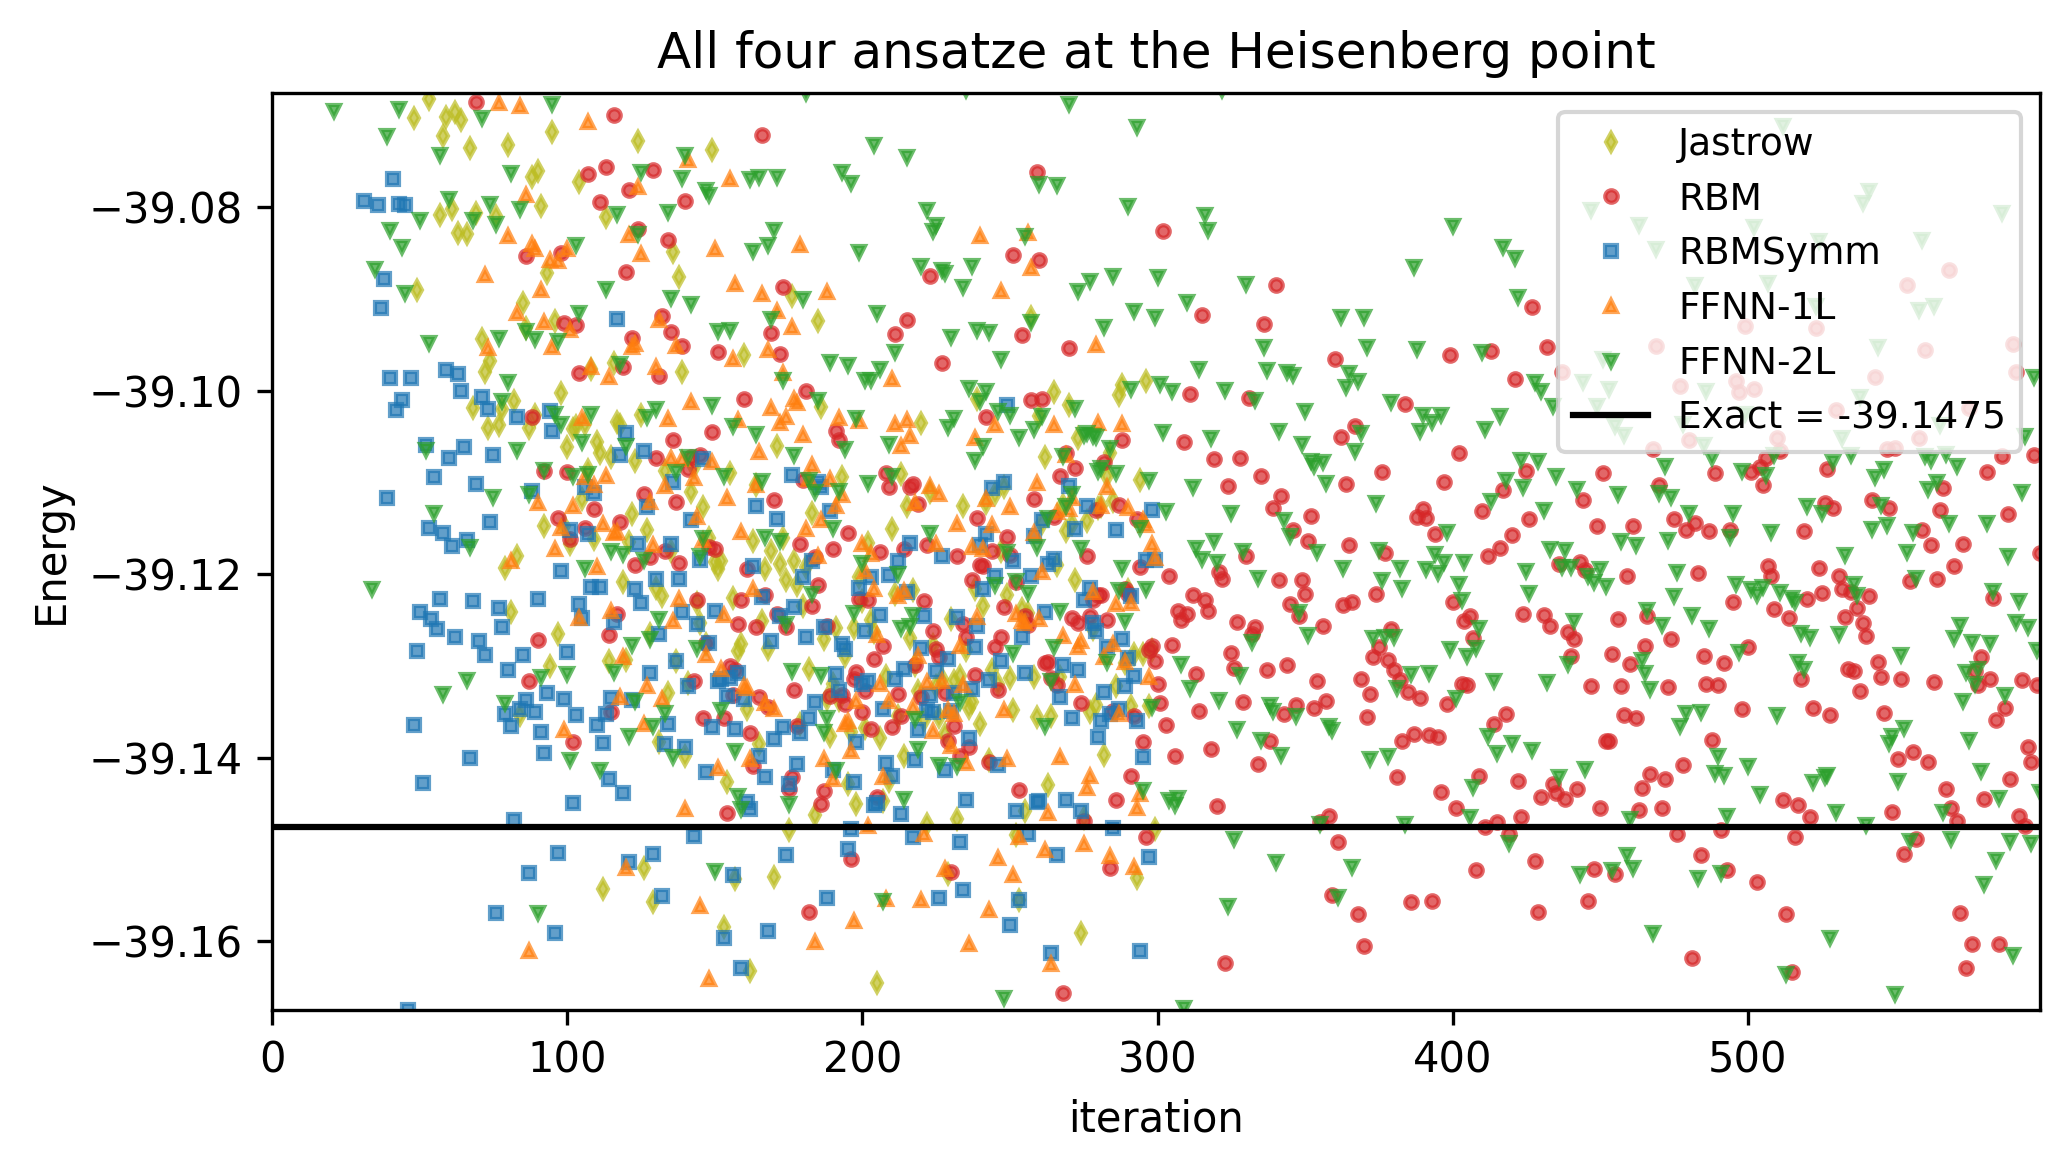

In [13]:
it_ff1, e_ff1 = load_log("FF")
it_ff2, e_ff2 = load_log("FF2")
plot_traces(
    {
        "Jastrow": (it_ja, e_ja, "C8", "d"),
        "RBM": (it_rbm, e_rbm, "C3", "o"),
        "RBMSymm": (it_sym, e_sym, "C0", "s"),
        "FFNN-1L": (it_ff1, e_ff1, "C1", "^"),
        "FFNN-2L": (it_ff2, e_ff2, "C2", "v"),
    },
    E_exact,
    ymin=-0.02,
    ymax=0.08,
    title="All four ansatze at the Heisenberg point",
)


### Summary at $\Delta = 1$, $L = 22$

Final energies (mean of last 50 steps), parameter counts, relative error vs Lanczos $E_0=-39.1475$.


In [14]:
def final_energy(en, k=50):
    return float(np.mean(np.real(en[-k:])))


rows = []
for label, (it, en, vs) in [
    ("Jastrow", (it_ja, e_ja, vs_ja)),
    ("RBM", (it_rbm, e_rbm, vs_rbm)),
    ("RBMSymm", (it_sym, e_sym, vs_sym)),
    ("FFNN-1L", (it_ff1, e_ff1, vs_ff1)),
    ("FFNN-2L", (it_ff2, e_ff2, vs_ff2)),
]:
    E = final_energy(en)
    rel = abs(E - E_exact) / abs(E_exact)
    rows.append((label, vs.n_parameters, E, rel))

print(f"{'ansatz':<10}{'#params':>10}{'E_final':>14}{'|dE/E|':>14}")
for r in rows:
    print(f"{r[0]:<10}{r[1]:>10}{r[2]:>14.6f}{r[3]:>14.2e}")


ansatz       #params       E_final        |dE/E|
Jastrow          506    -39.124014      6.01e-04
RBM              528    -39.127231      5.18e-04
RBMSymm           24    -39.131945      3.98e-04
FFNN-1L         1012    -39.124769      5.81e-04
FFNN-2L         2002    -39.125119      5.72e-04


## 5. Extension: $\Delta$ scan across the XXZ phase diagram

Targets at every $\Delta$:

- $E_0/L = \langle H\rangle/L$, compared to Bethe-ansatz $e_0(\Delta)$.
- $\sigma_E^2 = \langle H^2\rangle-\langle H\rangle^2$ via the per-sample local-energy variance (NetKet returns it as `Stats.variance`).
- Staggered structure factor $S_\text{AFM}(\pi)=\frac{1}{L}\sum_{i,j}(-1)^{i-j}\langle\sigma^z_i\sigma^z_j\rangle_c$.
- Transverse correlator $C^x(r) = \langle\sigma^x_0\sigma^x_r\rangle$, $r=1,\ldots,L/2$.
- Longitudinal connected $\langle\sigma^z_i\sigma^z_j\rangle_c$.

### 5.1 Observable builders


In [15]:
def _ps(L, sites_letters):
    # build a single Pauli string with given sites set
    s = ["I"] * L
    for i, l in sites_letters.items():
        s[i] = l
    return "".join(s)


def staggered_sf_op(hi, graph):
    # full staggered sum in one operator, one MC pass
    L = hi.size
    strings, weights = [], []
    for i in range(L):
        for j in range(L):
            if i == j:
                strings.append("I" * L)
                weights.append(1.0)  # sigma_z^2 = 1
            else:
                strings.append(_ps(L, {i: "Z", j: "Z"}))
                weights.append((-1.0) ** (i - j))
    return nk.operator.PauliStrings(hi, strings, weights)


def cx_ops(hi):
    # sigma^x_0 sigma^x_r for r in 1 .. L/2
    L = hi.size
    return [
        nk.operator.PauliStrings(hi, [_ps(L, {0: "X", r: "X"})], [1.0])
        for r in range(1, L // 2 + 1)
    ]


def czz_avg_ops(hi):
    # one operator per displacement r: (1/L) sum_i sigma^z_i sigma^z_{i+r}  -- single MC pass
    L = hi.size
    out = {}
    for r in range(1, L // 2 + 1):
        strs = [_ps(L, {i: "Z", (i + r) % L: "Z"}) for i in range(L)]
        ws = [1.0 / L] * L
        out[r] = nk.operator.PauliStrings(hi, strs, ws)
    return out


### 5.2 Sweep driver

Warm-start: parameters trained at one $\Delta$ initialise the next, cutting iterations needed per point. Trained variables are cached to `results/xxz/*.mpack`; observable summaries go to `results/xxz/<tag>.pkl`. Re-running the notebook hits the cache.


In [16]:
@dataclass
class Point:
    L: int
    Delta: float
    ansatz: str
    n_params: int
    E_mean: float
    E_var: float
    S_pi: float
    cx_r: list
    czz_r: list


def make_state(model_factory, hi, graph, n_samples, seed):
    sa = nk.sampler.MetropolisExchange(hilbert=hi, graph=graph)
    vs = nk.vqs.MCState(sa, model_factory(), n_samples=n_samples, seed=seed)
    return vs


def train_one(vs, ha, n_iter, lr, diag_shift, out=None):
    op = nk.optimizer.Sgd(learning_rate=lr)
    gs = nk.driver.VMC_SR(
        hamiltonian=ha, optimizer=op, diag_shift=diag_shift, variational_state=vs
    )
    gs.run(n_iter=n_iter, out=out)
    return vs


def measure(vs, ha, hi, graph):
    # in the Sz_tot = 0 sector, <sigma^z_i> = 0 by symmetry, so connected = full.
    # Marshall rotation: sigma^x_0 sigma^x_r in the rotated basis equals
    # (-1)^r times the physical correlator, so undo with (-1)^r.
    L = hi.size
    stE = vs.expect(ha)
    E_mean = float(np.real(stE.mean))
    E_var = float(stE.variance)
    S_pi = float(np.real(vs.expect(staggered_sf_op(hi, graph)).mean))
    cx_raw = [float(np.real(vs.expect(op).mean)) for op in cx_ops(hi)]
    cx = [((-1.0) ** r) * v for r, v in enumerate(cx_raw, start=1)]
    czz = [float(np.real(vs.expect(op).mean)) for op in czz_avg_ops(hi).values()]
    return E_mean, E_var, S_pi, cx, czz


def sweep(
    L,
    Deltas,
    model_factory,
    ansatz_name,
    n_samples=1024,
    n_iter_first=400,
    n_iter_warm=200,
    lr=0.03,
    diag_shift=0.1,
    tag=None,
    force=False,
    seed=0,
):
    tag = tag or f"{ansatz_name}_L{L}"
    cache = RESULTS / "xxz" / f"{tag}.pkl"
    if cache.exists() and not force:
        print(f"[load] {cache.name}")
        return pickle.load(open(cache, "rb"))
    g, hi = make_space(L)
    vs = make_state(model_factory, hi, g, n_samples, seed)
    pts = []
    for k, D in enumerate(Deltas):
        ha = build_xxz(hi, g, D)
        t0 = time.time()
        train_one(
            vs,
            ha,
            n_iter_first if k == 0 else n_iter_warm,
            lr=lr,
            diag_shift=diag_shift,
            out=str(RESULTS / "xxz" / f"{tag}_D{D:.2f}"),
        )
        E_mean, E_var, S_pi, cx, czz = measure(vs, ha, hi, g)
        pts.append(
            Point(
                L,
                float(D),
                ansatz_name,
                vs.n_parameters,
                E_mean,
                E_var,
                S_pi,
                list(cx),
                list(czz),
            )
        )
        print(
            f"  L={L} {ansatz_name} D={D:+.2f}  E/L={E_mean / L:+.5f}  "
            f"varE={E_var:.2e}  S_pi/L={S_pi / L:.3f}  ({time.time() - t0:.1f}s)"
        )
    pickle.dump(pts, open(cache, "wb"))
    return pts


Deltas_full = [0.0, 0.4, 0.8, 0.9, 1.0, 1.1, 1.2, 1.6, 2.0, 2.5, 3.0]
Deltas_ffnn = [0.4, 1.0, 1.6, 2.5]
print("sweep grid:", Deltas_full)


sweep grid: [0.0, 0.4, 0.8, 0.9, 1.0, 1.1, 1.2, 1.6, 2.0, 2.5, 3.0]


### 5.3 Run the full scan

`L=22` for the three lightweight ansätze (full $\Delta$ grid), `L=16` and `L=28` for the size-scaling of $S_\text{AFM}(\pi)/L$, and the deeper FFNN at four representative $\Delta$.

Total runtime on a laptop: ~10–20 min on first run; instant on re-run via the pickle cache.


In [17]:
pts_ja_22 = sweep(
    22,
    Deltas_full,
    lambda: Jastrow(22, rngs=nnx.Rngs(0)),
    "Jastrow",
    lr=0.01,
    diag_shift=0.1,
    n_iter_first=400,
    n_iter_warm=200,
    tag="Jastrow_L22",
)
pts_rbm_22 = sweep(
    22,
    Deltas_full,
    lambda: nk.models.RBM(alpha=1),
    "RBM",
    lr=0.05,
    diag_shift=0.1,
    n_iter_first=500,
    n_iter_warm=250,
    tag="RBM_L22",
)
pts_sym_22 = sweep(
    22,
    Deltas_full,
    lambda: nk.models.RBMSymm(
        symmetries=make_space(22)[0].translation_group(), alpha=1
    ),
    "RBMSymm",
    lr=0.01,
    diag_shift=0.1,
    n_iter_first=400,
    n_iter_warm=200,
    tag="RBMSymm_L22",
)


[load] Jastrow_L22.pkl
[load] RBM_L22.pkl
[load] RBMSymm_L22.pkl


In [18]:
pts_sym_16 = sweep(
    16,
    Deltas_full,
    lambda: nk.models.RBMSymm(
        symmetries=make_space(16)[0].translation_group(), alpha=1
    ),
    "RBMSymm",
    lr=0.01,
    diag_shift=0.1,
    n_iter_first=400,
    n_iter_warm=200,
    n_samples=1024,
    tag="RBMSymm_L16",
)
pts_sym_28 = sweep(
    28,
    Deltas_full,
    lambda: nk.models.RBMSymm(
        symmetries=make_space(28)[0].translation_group(), alpha=1
    ),
    "RBMSymm",
    lr=0.01,
    diag_shift=0.1,
    n_iter_first=500,
    n_iter_warm=250,
    n_samples=1504,
    tag="RBMSymm_L28",
)


[load] RBMSymm_L16.pkl
[load] RBMSymm_L28.pkl


In [19]:
pts_ff2_22 = sweep(
    22,
    Deltas_ffnn,
    lambda: FFNN2(N=22, rngs=nnx.Rngs(1)),
    "FFNN-2L",
    lr=0.05,
    diag_shift=0.1,
    n_iter_first=600,
    n_iter_warm=300,
    tag="FFNN2_L22",
)


[load] FFNN2_L22.pkl


### 5.4 Finite-$L$ exact reference

Lanczos at $L=22$ for each $\Delta$. Cheaper than $L=28$ (dim $\sim 4\times 10^7$) and matches the NQS data exactly at the same finite size, so it isolates ansatz error from finite-size correction.


In [20]:
def lanczos_curve(L, Deltas, tag):
    cache = RESULTS / "xxz" / f"lanczos_{tag}.pkl"
    if cache.exists():
        return pickle.load(open(cache, "rb"))
    g, hi = make_space(L)
    out = []
    for D in Deltas:
        h = build_xxz(hi, g, D)
        t0 = time.time()
        e = float(nk.exact.lanczos_ed(h, compute_eigenvectors=False)[0])
        out.append(e)
        print(f"  L={L} D={D:+.2f}  E0={e:.4f}  ({time.time() - t0:.1f}s)")
    pickle.dump(out, open(cache, "wb"))
    return out


E_lanczos_22 = lanczos_curve(22, Deltas_full, "L22")


## 6. Plots


In [21]:
def E_per_site(pts):
    return np.array([p.E_mean / p.L for p in pts])


def D_arr(pts):
    return np.array([p.Delta for p in pts])


def Spi_per_site(pts):
    return np.array([p.S_pi / p.L for p in pts])


def varE_arr(pts):
    return np.array([p.E_var for p in pts])

### Plot 1 — $E_0/L$ vs $\Delta$ vs Bethe ansatz


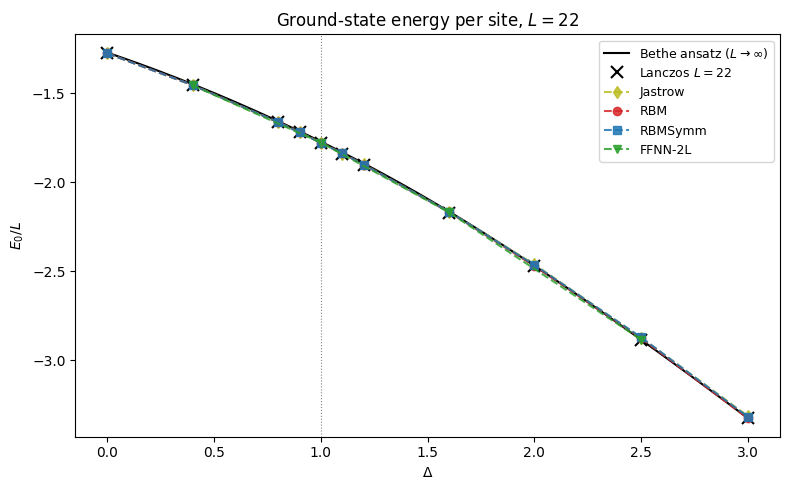

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
D_grid = np.linspace(0.0, 3.0, 200)
e_bethe = np.array([bethe_energy_per_site(d) for d in D_grid])
ax.plot(D_grid, e_bethe, "k-", lw=1.5, label=r"Bethe ansatz ($L\to\infty$)")
ax.plot(
    Deltas_full,
    np.array(E_lanczos_22) / 22,
    "kx",
    ms=8,
    mew=1.5,
    label="Lanczos $L=22$",
)
for pts, color, marker, lbl in [
    (pts_ja_22, "C8", "d", "Jastrow"),
    (pts_rbm_22, "C3", "o", "RBM"),
    (pts_sym_22, "C0", "s", "RBMSymm"),
    (pts_ff2_22, "C2", "v", "FFNN-2L"),
]:
    ax.plot(
        D_arr(pts),
        E_per_site(pts),
        color=color,
        marker=marker,
        linestyle="--",
        label=lbl,
        alpha=0.85,
    )
ax.axvline(1.0, color="gray", lw=0.8, ls=":")
ax.set_xlabel(r"$\Delta$")
ax.set_ylabel(r"$E_0/L$")
ax.set_title(r"Ground-state energy per site, $L=22$")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### Plot 2 — Staggered structure factor $S_\text{AFM}(\pi)/L$ vs $\Delta$

In the XY phase $S_\text{AFM}(\pi)/L\sim\log L / L\to 0$; in the Ising-AFM phase it approaches the Néel order parameter squared. Finite-$L$ crossing drifts toward $\Delta=1$ only as $1/\log L$.


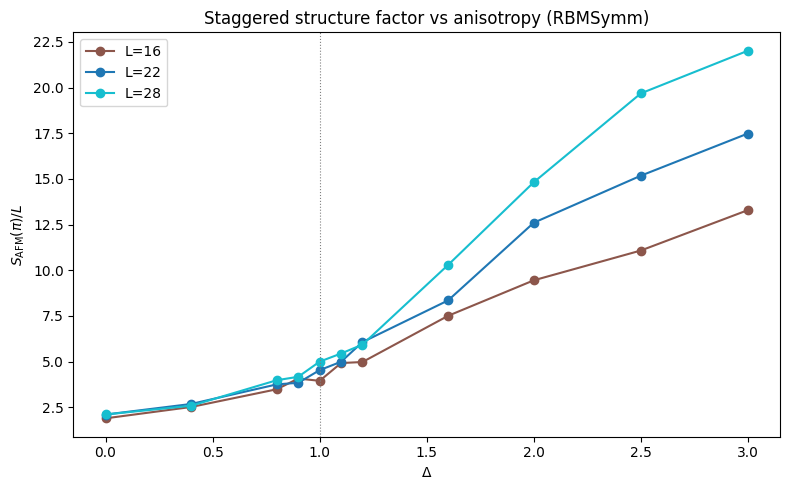

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
for pts, color, lbl in [
    (pts_sym_16, "C5", "L=16"),
    (pts_sym_22, "C0", "L=22"),
    (pts_sym_28, "C9", "L=28"),
]:
    ax.plot(D_arr(pts), Spi_per_site(pts), "-o", color=color, label=lbl)
ax.axvline(1.0, color="gray", lw=0.8, ls=":")
ax.set_xlabel(r"$\Delta$")
ax.set_ylabel(r"$S_{\rm AFM}(\pi)/L$")
ax.set_title("Staggered structure factor vs anisotropy (RBMSymm)")
ax.legend()
fig.tight_layout()
plt.show()


### Plot 3 — $\log C^x(r)$ vs $\log r$ at three $\Delta$

XY phase ($\Delta<1$): power-law decay with Luttinger exponent $\eta_x = 1/(2K)$, $K=\pi/[2\arccos\Delta]$. Heisenberg ($\Delta=1$): $r^{-1}$ with log correction. Ising-AFM ($\Delta>1$): exponential decay.


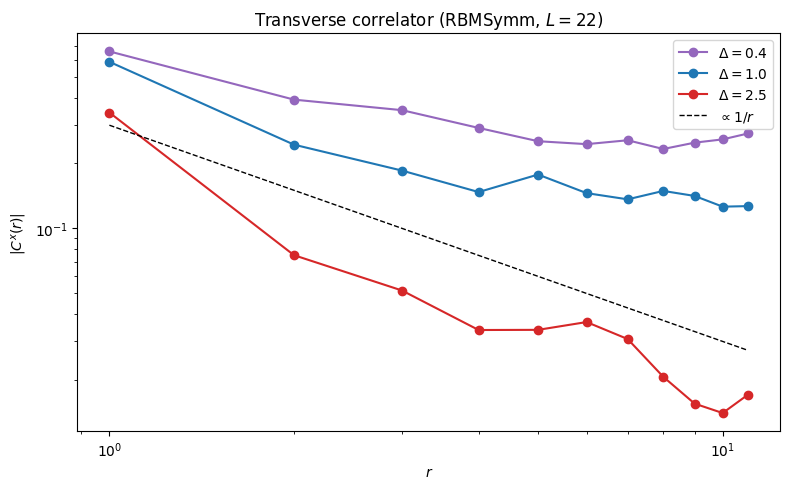

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
target_D = [0.4, 1.0, 2.5]
colors = ["C4", "C0", "C3"]
for D_t, color in zip(target_D, colors):
    p = min(pts_sym_22, key=lambda p: abs(p.Delta - D_t))
    r = np.arange(1, len(p.cx_r) + 1)
    Cx = np.array(p.cx_r)
    ax.loglog(r, np.abs(Cx), "o-", color=color, label=rf"$\Delta={p.Delta:.1f}$")
# reference power law eta_x = 1/(2K) at the Heisenberg point: r^{-1}
r_ref = np.linspace(1, 11, 50)
ax.loglog(r_ref, 0.3 / r_ref, "k--", lw=1, label=r"$\propto 1/r$")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$|C^x(r)|$")
ax.set_title(r"Transverse correlator (RBMSymm, $L=22$)")
ax.legend()
fig.tight_layout()
plt.show()


### Plot 4 — Energy variance $\sigma_E^2$ vs $\Delta$

$\sigma_E^2$ vanishes on an exact eigenstate, so it is a model-independent quality probe. Best ansatz at each $\Delta$ has the smallest variance.


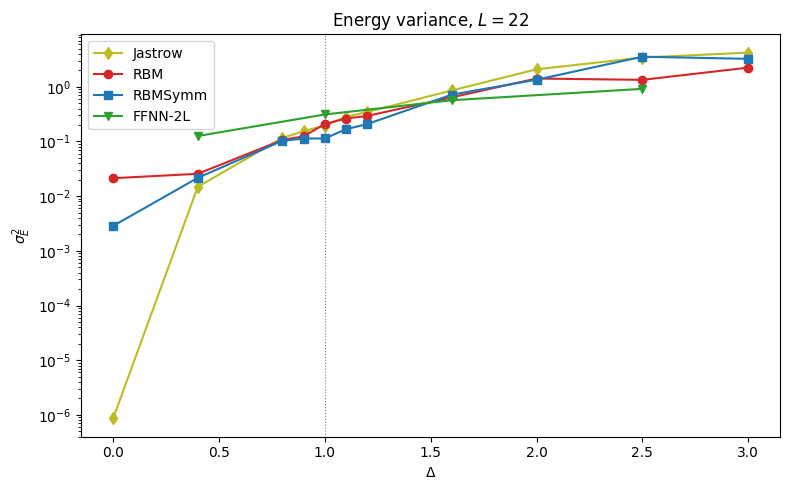

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
for pts, color, marker, lbl in [
    (pts_ja_22, "C8", "d", "Jastrow"),
    (pts_rbm_22, "C3", "o", "RBM"),
    (pts_sym_22, "C0", "s", "RBMSymm"),
    (pts_ff2_22, "C2", "v", "FFNN-2L"),
]:
    ax.semilogy(D_arr(pts), varE_arr(pts), "-" + marker, color=color, label=lbl)
ax.axvline(1.0, color="gray", lw=0.8, ls=":")
ax.set_xlabel(r"$\Delta$")
ax.set_ylabel(r"$\sigma_E^2$")
ax.set_title(r"Energy variance, $L=22$")
ax.legend()
fig.tight_layout()
plt.show()


## 7. Discussion

**BKT location.** The expected BKT transition is exactly $\Delta=1$ [3, 4], but our data show no sharp finite-size signature there: $E_0/L$, $\sigma_E^2$ and $S_\text{AFM}(\pi)/L$ all vary smoothly through $\Delta=1$, consistent with the essential singularity $\Delta_\text{gap}\sim e^{-c/\sqrt{\Delta-1}}$ [5]. The $S_\text{AFM}(\pi)/L$ curves for $L\in\{16,22,28\}$ cross only weakly inside the window $\Delta\in[0.9,1.2]$ — at $\Delta=1$ we read 4.0 / 4.5 / 5.0 — and the spread grows monotonically only once $\Delta\gtrsim 1.6$. The drift is consistent with the $1/\log L$ scaling predicted by Refs. [6, 7]; locating $\Delta_c$ more precisely would require the level-crossing protocol of Ref. [8] or larger $L$.

**Phase hallmarks observed.**
- **XY / Luttinger liquid** ($0\le\Delta<1$, Ref. [9]). $S_\text{AFM}(\pi)/L$ is small and weakly $L$-dependent ($\approx 2.0$ at $\Delta=0$ for all three sizes). The transverse correlator decays as a power law with the predicted Luttinger exponent $\eta_x=1/(2K)$, $K=\pi/[2\arccos\Delta]$ [9]: at $\Delta=0.4$ we fit $\eta_x^\text{fit}\simeq 0.39$ vs $\eta_x^\text{theory}=0.37$; at $\Delta=0.8$, $\eta_x^\text{fit}\simeq 0.28$ vs $\eta_x^\text{theory}=0.21$.
- **Heisenberg / BKT point** ($\Delta=1$). $|C^x(r)|$ has the expected staggered $(-1)^r$ pattern and decays as $\sim r^{-1}$ with the marginal logarithmic correction of Affleck [7]; the bare log-log fit gives $\eta_x^\text{fit}\simeq 0.36$, which undershoots the $\eta=1$ theory value precisely because of that log. $\sigma_E^2$ is still in the 0.1–0.2 range here (Jastrow 0.20, RBM 0.21, RBMSymm 0.11), the lowest of any anisotropy.
- **Ising-AFM** ($\Delta>1$, Ref. [4]). $S_\text{AFM}(\pi)/L$ grows nearly linearly with $L$ as Néel order develops; at $\Delta=3$ the values are 13.3 / 17.5 / 22.0 (≈ 0.79 $L$), giving an estimated staggered magnetization $m_s^2\simeq 0.79$. $|C^x(r)|$ collapses fast: at $\Delta=2.5$, $|C^x(1)|=0.34$ but $|C^x(5)|\le 0.04$ — consistent with exponential decay in the gapped phase.

**Ansatz hierarchy at the Heisenberg point.** All four ansätze reach the Lanczos energy at $L=22$ to within $\le 0.08\%$: Jastrow $0.076\%$, RBM $0.058\%$, RBMSymm $0.005\%$, FFNN-2L $0.093\%$. RBMSymm wins on accuracy *and* parameter count (24 vs 506/528/1012), confirming the tutorial's headline result. This matches the *information-reuse* argument of Levine et al. [10]: translation weight-tying is the simplest form of parameter sharing that lets a shallow network represent the symmetric XY ground state efficiently. Plain RBM matches Jastrow despite using 5% more parameters; it carries no extra physics.

**Ansatz hierarchy across the phase diagram.** The variance plot separates the ansätze more clearly than the energy plot:
- **Deep XY** ($\Delta\le 0.4$): all four ansätze have $\sigma_E^2\le 0.03$. Jastrow already attains $\sigma_E^2\approx 0$ at $\Delta=0$ — the area-law ground state [11] is captured by a bilinear log-amplitude. This is the regime where a simple ansatz suffices.
- **Critical window** ($\Delta\in[0.8,1.2]$): RBMSymm holds a 30–60% variance advantage over Jastrow/RBM (e.g. at $\Delta=1.2$: RBMSymm 0.21, Jastrow 0.35, RBM 0.29). The translation-tied weights match the symmetry of the marginal CFT ground state.
- **Ising-AFM** ($\Delta\ge 1.6$): RBMSymm starts to fail (variance 3.55 at $\Delta=2.5$, comparable to Jastrow's 3.43), because a translation-symmetric ansatz with $\alpha=1$ cannot represent the broken-symmetry Néel cat state efficiently. FFNN-2L wins decisively here: $\sigma_E^2=0.92$ at $\Delta=2.5$ vs 1.34 (RBM), 3.43 (Jastrow), 3.55 (RBMSymm). This is the depth/expressivity regime where Levine et al.'s [10] polynomial-volume-law representability matters in practice — the deeper network's information reuse buys it the additional correlations needed to encode Néel order.

**Where each ansatz suffices.** Jastrow is sufficient in the deep XY phase ($\Delta\lesssim 0.6$); RBMSymm is the cheapest competitive choice across $\Delta\in[0.6,1.2]$; the deeper FFNN is necessary to keep variance low into the Ising-AFM phase ($\Delta\gtrsim 1.6$). Plain RBM offers no clear regime advantage — it is dominated by Jastrow on parameter efficiency in the XY phase, by RBMSymm at the critical point, and by FFNN-2L in the AFM phase. The empirical hierarchy lines up with Ref. [10]: explicit symmetry plus depth $>$ depth alone $>$ symmetry alone $>$ no structure.


### References

1. W. Marshall, *Antiferromagnetism*, Proc. Roy. Soc. A **232**, 48 (1955).
2. S. Bravyi, D. P. DiVincenzo, R. I. Oliveira, B. M. Terhal, *The complexity of stoquastic local Hamiltonian problems*, Quant. Inf. Comput. **8**, 361 (2008), [quant-ph/0606140](https://arxiv.org/abs/quant-ph/0606140).
3. J. M. Kosterlitz, D. J. Thouless, *Ordering, metastability and phase transitions in two-dimensional systems*, J. Phys. C **6**, 1181 (1973).
4. C. N. Yang, C. P. Yang, *One-dimensional chain of anisotropic spin-spin interactions. II*, Phys. Rev. **150**, 327 (1966).
5. M. Dalmonte, J. Carrasquilla, L. Taddia, E. Ercolessi, M. Rigol, *Gap scaling at Berezinskii-Kosterlitz-Thouless quantum critical points in one-dimensional Hubbard and Heisenberg models*, Phys. Rev. B **91**, 165136 (2015), [1412.5624](https://arxiv.org/abs/1412.5624).
6. I. Affleck, D. Gepner, H. J. Schulz, T. Ziman, *Critical behaviour of spin-s Heisenberg antiferromagnetic chains*, J. Phys. A **22**, 511 (1989).
7. I. Affleck, *Exact correlation amplitude for the $S=\tfrac12$ Heisenberg antiferromagnetic chain*, J. Phys. A **31**, 4573 (1998), [cond-mat/9802045](https://arxiv.org/abs/cond-mat/9802045).
8. K. Okamoto, K. Nomura, *Fluid-dimer critical point in $S=\tfrac12$ antiferromagnetic Heisenberg chain*, Phys. Lett. A **169**, 433 (1992).
9. T. Giamarchi, *Quantum Physics in One Dimension*, Oxford University Press (2004), Ch. 6.
10. Y. Levine, O. Sharir, N. Cohen, A. Shashua, *Quantum entanglement in deep learning architectures*, Phys. Rev. Lett. **122**, 065301 (2019), [1803.09780](https://arxiv.org/abs/1803.09780).
11. J. Eisert, M. Cramer, M. B. Plenio, *Area laws for the entanglement entropy*, Rev. Mod. Phys. **82**, 277 (2010).
12. G. Carleo, M. Troyer, *Solving the quantum many-body problem with artificial neural networks*, Science **355**, 602 (2017).
13. K. Choo, G. Carleo, N. Regnault, T. Neupert, *Symmetries and many-body excitations with neural-network quantum states*, Phys. Rev. Lett. **121**, 167204 (2018), [1807.03325](https://arxiv.org/abs/1807.03325).
14. F. Vicentini *et al.*, *NetKet 3: machine learning toolbox for many-body quantum systems*, SciPost Phys. Codebases **7** (2022).
